In [12]:
#pip install google-api-python-client google-auth-httplib2 google-auth-oauthlib

In [13]:
#from google.oauth2.credentials import Credentials

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

%matplotlib inline

---
# **_▞▞ Configuration ▞▞_**

All key hyperparameters in one place.

### Single-lead vs 12-lead
To use only **one lead**, set `N_LEADS = 1` and `LEAD_INDEX` to the lead you want:
- `0` = Lead I, `1` = Lead II, `2` = Lead III
- `3`–`5` = aVR, aVL, aVF
- `6`–`11` = V1–V6

Set `N_LEADS = 12` and `LEAD_INDEX = None` to use all leads.

---

In [16]:
# ============================================================
#  CONFIGURATION — change these to switch modes easily
# ============================================================

# Lead configuration
N_LEADS     = 12          # Number of input channels: 1 or 12
LEAD_INDEX  = None        # None = all leads; 0-11 = specific lead (only used if N_LEADS=1)
                          # Example for single lead II: N_LEADS=1, LEAD_INDEX=1

# Model architecture
FILTERS     = 32          # Conv1 filters
KSIZE       = 5           # Kernel size
OUTFEAT     = 12          # Number of arrhythmia classes

# Training
EPOCHS      = 10
BATCH_SIZE  = 32
LR          = 1e-3        # FIX: was 0.01, too high; 1e-3 is standard for Adam
PATIENCE    = 7           # Early stopping patience (epochs without val improvement)
DROPOUT_P   = 0.5         # Dropout probability

# Data
RANDOMIZER  = 42
TESTSIZE    = 0.15
VALSIZE     = 0.15
SR_RATIO    = 0.5         # Keep only 50% of SR samples to reduce class imbalance

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
# **_▞▞ Load & Understand the Data ▞▞_**

Dataset: PTB-XL (Wagner et al., 2022 — PhysioNet)

Columns used:
- `rhythm_labels` → arrhythmia type to predict
- `filename_lr` → path to the raw `.dat` ECG file
---

In [17]:
file = r'/content/drive/MyDrive/TESIS-V2/Data/ptb-xl-1.0.3/dataset_statements.csv'
filecsv = pd.read_csv(file)
print(f"Dataset shape: {filecsv.shape}")
filecsv.head()

Dataset shape: (21030, 6)


,ecg_id,rhythm_labels,filename_lr,strat_fold,age,sex
0,1,['SR'],records100/00000/00001_lr,3,56.0,1
1,2,['SBRAD'],records100/00000/00002_lr,2,19.0,0
2,3,['SR'],records100/00000/00003_lr,5,37.0,1
3,4,['SR'],records100/00000/00004_lr,3,24.0,0
4,5,['SR'],records100/00000/00005_lr,4,19.0,1


In [18]:
filecsv.describe()

,ecg_id,strat_fold,age,sex
count,21030.000000,21030.000000,21030.000000,21030.000000
mean,10977.709558,5.498288,62.483357,0.483119
std,6298.341526,2.871157,32.057009,0.499727
min,1.000000,1.000000,2.000000,0.000000
25%,5533.250000,3.000000,50.000000,0.000000
50%,10992.500000,5.000000,61.000000,0.000000
75%,16432.750000,8.000000,72.000000,1.000000
max,21837.000000,10.000000,300.000000,1.000000


---
# **_▞▞ Dataset Class ▞▞_**

Key improvements over the previous version:
- **Single-lead support**: Pass `lead_index=0` through `11` to extract only one lead from the 12-channel signal.
- **Class weight computation**: Returns weights to pass into `CrossEntropyLoss` to handle class imbalance.
- **Uses `rhythm_labels` column** (which actually exists in `dataset_statements.csv`).
---

In [19]:
arrhythmia_map = {
    'SR': 0, 'AFIB': 1, 'STACH': 2, 'SARRH': 3,
    'SBRAD': 4, 'PACE': 5, 'SVARR': 6, 'BIGU': 7,
    'AFLT': 8, 'SVTAC': 9, 'PSVT': 10, 'TRIGU': 11
}

# Human-readable names for plots
CLASS_NAMES = [
    'SR', 'AFIB', 'STACH', 'SARRH',
    'SBRAD', 'PACE', 'SVARR', 'BIGU',
    'AFLT', 'SVTAC', 'PSVT', 'TRIGU'
]


class PTBXLDataset(Dataset):
    def __init__(
        self,
        csv_file,
        root_path,
        subset_folder="records100",
        max_samples=None,
        downsample_sr=False,
        sr_ratio=1.0,
        random_state=42,
        lead_index=None      # NEW: None = all 12 leads; 0-11 = single lead
    ):
        self.root_path  = root_path
        self.lead_index = lead_index
        self.df         = pd.read_csv(csv_file)

        if subset_folder is not None:
            self.df = self.df[self.df["filename_lr"].str.startswith(subset_folder)].copy()

        # ── Label extraction ─────────────────────────────────────────
        def get_label(code_str):
            code_str = str(code_str)
            for name, index in arrhythmia_map.items():
                if name in code_str:
                    return index
            return 11  # default: TRIGU / unknown

        # dataset_statements.csv uses 'rhythm_labels'
        label_col = "rhythm_labels" if "rhythm_labels" in self.df.columns else "scp_codes"
        self.df["target"] = self.df[label_col].apply(get_label)
        self.df["target"] = pd.to_numeric(self.df["target"], errors="coerce")
        self.df = self.df.dropna(subset=["target"]).copy()
        self.df["target"] = self.df["target"].astype(np.int64)

        if max_samples is not None:
            self.df = self.df.sample(max_samples, random_state=random_state).copy()

        # ── Downsample dominant SR class ─────────────────────────────
        if downsample_sr:
            sr_df    = self.df[self.df["target"] == 0].copy()
            non_sr   = self.df[self.df["target"] != 0].copy()
            sr_keep  = min(int(len(non_sr) * sr_ratio), len(sr_df))
            sr_df    = sr_df.sample(n=sr_keep, random_state=random_state)
            self.df  = pd.concat([sr_df, non_sr], axis=0)
            self.df  = self.df.sample(frac=1, random_state=random_state).reset_index(drop=True)

        self.df = self.df.reset_index(drop=True)

        print(f"Total records loaded: {len(self.df)}")
        print("\nClass distribution:")
        dist = self.df["target"].value_counts().sort_index()
        for idx, count in dist.items():
            print(f"  {idx:2d} ({CLASS_NAMES[idx]:6s}): {count}")

    def get_class_weights(self):
        """Compute inverse-frequency weights for CrossEntropyLoss."""
        labels = self.df["target"].values
        weights = compute_class_weight(
            class_weight="balanced",
            classes=np.arange(OUTFEAT),
            y=labels
        )
        return torch.tensor(weights, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.root_path, row["filename_lr"] + ".dat")

        with open(file_path, "rb") as f:
            data = np.fromfile(f, dtype=np.int16).reshape(1000, 12)

        # Shape after .T: (12, 1000)  → one row per lead
        x = torch.tensor(data, dtype=torch.float32).T / 1000.0

        # ── Single-lead mode ─────────────────────────────────────────
        # If lead_index is set, extract just that one channel.
        # Result shape: (1, 1000) — still a 2-D tensor, compatible with Conv1d.
        if self.lead_index is not None:
            x = x[self.lead_index].unsqueeze(0)  # (1, 1000)

        y = torch.tensor(int(row["target"]), dtype=torch.long)
        return x, y

---
# **_▞▞ Model Architecture ▞▞_**

### Fixes from the previous version:
1. **Dropout is now actually USED** in `forward()` — it was defined before but never called.
2. **BatchNorm1d** added after each conv layer — normalizes activations, stabilizes training, and acts as additional regularization alongside dropout.
3. **Adaptive pooling** before the FC layer — removes the hard-coded `15808` flat size, so the model works whether you use 12 leads or 1.
4. **Deeper architecture** — 3 conv blocks instead of 2, so the model can learn more complex patterns without memorizing.

### How pooling works for 1D raw data
MaxPool1d works perfectly for raw ECG signals — it slides a window over the time axis and keeps the strongest activation, which compresses the sequence and makes the model focus on the most prominent features (like QRS peaks) rather than every sample.

---

In [20]:
class ECGModel(nn.Module):
    def __init__(self, n_leads=12, n_classes=12, dropout_p=0.5):
        super().__init__()

        # ── Convolutional blocks ──────────────────────────────────────
        # Each block: Conv1d → BatchNorm → ReLU → MaxPool
        # BatchNorm stabilizes training and provides regularization
        self.conv1 = nn.Conv1d(n_leads, 32,  kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32,      64,  kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64,      128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        self.pool    = nn.MaxPool1d(2)

        # AdaptiveAvgPool1d(4) → always outputs 128*4=512 features
        # regardless of input length or number of leads.
        # This removes the fragile hard-coded flat size.
        self.global_pool = nn.AdaptiveAvgPool1d(4)

        # ── Fully connected ───────────────────────────────────────────
        self.dropout = nn.Dropout(dropout_p)
        self.fc1     = nn.Linear(128 * 4, 256)
        self.fc2     = nn.Linear(256, 128)
        self.out     = nn.Linear(128, n_classes)

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Adaptive pool → fixed-size feature vector
        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        # FIX: dropout is now actually applied!
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.out(x)

---
# **_▞▞ Load Data & Initialize Model ▞▞_**

Key changes:
- **Weighted CrossEntropyLoss** — penalizes errors on rare classes more, combating class imbalance.
- **Lower learning rate** (`1e-3`) — reduces risk of overshooting good minima.
- **ReduceLROnPlateau scheduler** — automatically halves the LR when val_loss stops improving.
---

In [21]:
csv_path  = '/content/drive/MyDrive/TESIS-V2/Data/ptb-xl-1.0.3/ptbxl_database.csv'
base_path = '/content/drive/MyDrive/TESIS-V2/Data/ptb-xl-1.0.3/'

dataset = PTBXLDataset(
    csv_file=csv_path,
    root_path=base_path,
    subset_folder="records100",
    max_samples=None,
    downsample_sr=True,
    sr_ratio=SR_RATIO,
    lead_index=LEAD_INDEX  # None = 12 leads; set 0-11 for single lead
)

# ── Train / Val / Test split ──────────────────────────────────────────
val_size   = int(VALSIZE * len(dataset))
test_size  = int(TESTSIZE * len(dataset))
train_size = len(dataset) - val_size - test_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOMIZER)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")

# ── Model ─────────────────────────────────────────────────────────────
model = ECGModel(n_leads=N_LEADS, n_classes=OUTFEAT, dropout_p=DROPOUT_P).to(device)
print(model)

# ── Weighted loss (FIX: handles class imbalance) ──────────────────────
class_weights = dataset.get_class_weights().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer + scheduler ─────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

Total records loaded: 7576

Class distribution:
   0 (SR    ): 2525
   1 (AFIB  ): 1514
   2 (STACH ): 826
   3 (SARRH ): 770
   4 (SBRAD ): 634
   5 (PACE  ): 285
   6 (SVARR ): 157
   7 (BIGU  ): 22
   8 (AFLT  ): 42
   9 (SVTAC ): 18
  10 (PSVT  ): 10
  11 (TRIGU ): 773
Train: 5304 | Val: 1136 | Test: 1136
ECGModel(
  (conv1): Conv1d(12, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool1d(output_size=4)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_

---
# **_▞▞ Training Loop with Early Stopping ▞▞_**

- **Early stopping** — saves the best model weights and stops training when val_loss hasn't improved for `PATIENCE` epochs.
- **LR scheduler** — steps after each epoch based on val_loss.
---

In [22]:
history = {
    'loss': [], 'accuracy': [], 'f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_f1': []
}

best_val_loss   = float('inf')
patience_counter = 0
best_model_path  = 'best_ecg_model.pt'

for epoch in range(EPOCHS):
    # ── TRAIN ────────────────────────────────────────────────────────
    model.train()
    train_loss, train_preds, train_labels = 0, [], []

    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()
        train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        train_labels.extend(batch_y.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1  = f1_score(train_labels, train_preds, average='weighted', zero_division=0)

    # ── VALIDATE ─────────────────────────────────────────────────────
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            val_loss += criterion(outputs, batch_y).item()
            val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            val_labels.extend(batch_y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1  = f1_score(val_labels, val_preds, average='weighted', zero_division=0)

    # ── Scheduler step ───────────────────────────────────────────────
    scheduler.step(avg_val_loss)


    # Print current LR so you can see when it changes
    current_lr = optimizer.param_groups[0]['lr']


    # ── History ──────────────────────────────────────────────────────
    history['loss'].append(avg_train_loss)
    history['accuracy'].append(train_acc)
    history['f1'].append(train_f1)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"loss: {avg_train_loss:.4f} | acc: {train_acc:.4f} | f1: {train_f1:.4f} || "
        f"val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.4f} | val_f1: {val_f1:.4f} | "
        f"lr: {current_lr:.6f}"   # ← added here
    )

    # ── Early stopping ───────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

print("\nTraining complete. Loading best model weights...")
model.load_state_dict(torch.load(best_model_path, weights_only=True))

Epoch 1/10:   0%|          | 0/166 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/10: 100%|██████████| 166/166 [55:16<00:00, 19.98s/batch] 
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/10] | loss: 2.4291 | acc: 0.1559 | f1: 0.1590 || val_loss: 2.1109 | val_acc: 0.1796 | val_f1: 0.1260 | lr: 0.001000
  ✓ Best model saved (val_loss=2.1109)


Epoch 2/10:   0%|          | 0/166 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 2/10: 100%|██████████| 166/166 [00:33<00:00,  4.95batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [2/10] | loss: 2.2801 | acc: 0.1959 | f1: 0.1843 || val_loss: 2.0223 | val_acc: 0.1831 | val_f1: 0.1042 | lr: 0.001000
  ✓ Best model saved (val_loss=2.0223)


Epoch 3/10:   0%|          | 0/166 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 3/10: 100%|██████████| 166/166 [00:36<00:00,  4.52batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 9/10:   0%|          | 0/166 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 9/10: 100%|██████████| 166/166 [00:36<00:00,  4.58batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [9/10] | loss: 1.7629 | acc: 0.3725 | f1: 0.3634 || val_loss: 1.6389 | val_acc: 0.3081 | val_f1: 0.2620 | lr: 0.001000
  ✓ Best model saved (val_loss=1.6389)


Epoch 10/10:   0%|          | 0/166 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 10/10: 100%|██████████| 166/166 [00:35<00:00,  4.73batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [10/10] | loss: 1.8095 | acc: 0.3675 | f1: 0.3575 || val_loss: 2.0563 | val_acc: 0.3125 | val_f1: 0.2370 | lr: 0.001000
  ✗ No improvement (1/7)

Training complete. Loading best model weights...


<All keys matched successfully>

---
# **_▞▞ Training Curves ▞▞_**
---

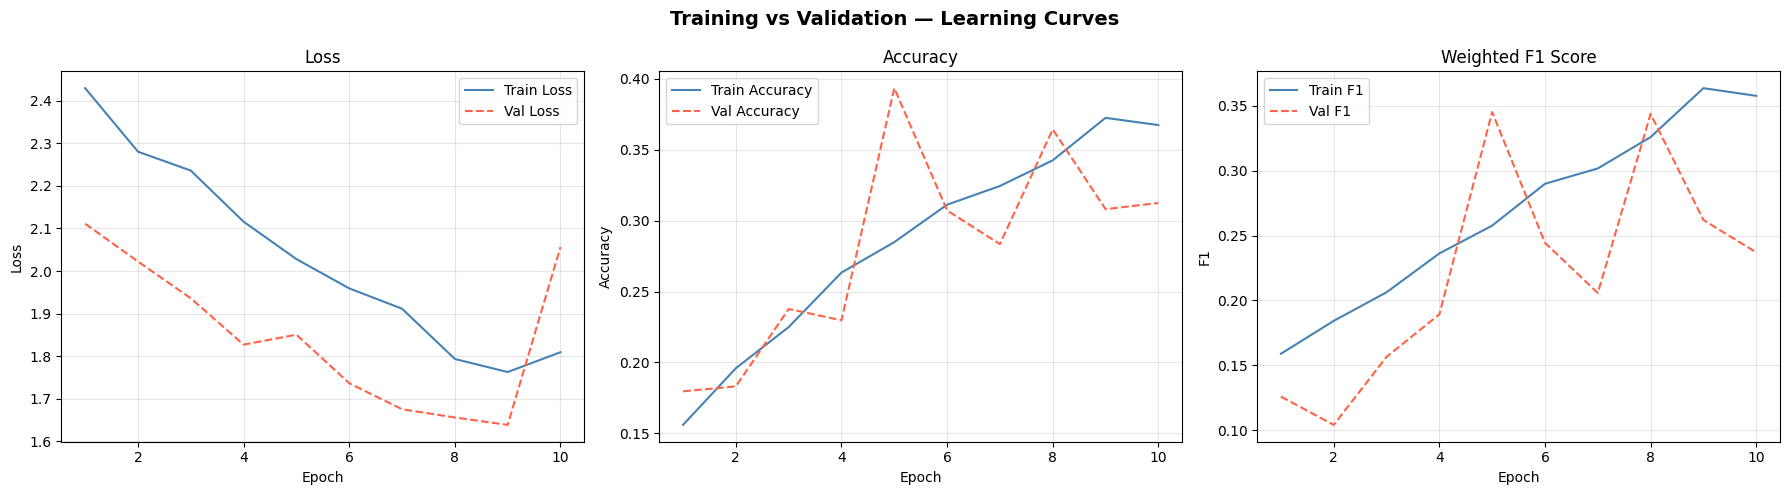

Saved: training_curves.png


In [23]:
epochs_ran = len(history['loss'])
x_axis     = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(x_axis, history['loss'],     label='Train Loss',    color='steelblue')
axes[0].plot(x_axis, history['val_loss'], label='Val Loss',      color='tomato', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x_axis, history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(x_axis, history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(x_axis, history['f1'],     label='Train F1', color='steelblue')
axes[2].plot(x_axis, history['val_f1'], label='Val F1',   color='tomato', linestyle='--')
axes[2].set_title('Weighted F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

---
# **_▞▞ Evaluation on Test Set ▞▞_**
---

In [24]:
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for batch_X, batch_y in tqdm(test_loader, desc="Evaluating on test set"):
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        test_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        test_labels.extend(batch_y.numpy())

test_acc  = accuracy_score(test_labels, test_preds)
test_f1   = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
test_prec = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
test_rec  = recall_score(test_labels, test_preds, average='weighted', zero_division=0)

print("="*55)
print(f"  TEST SET RESULTS")
print("="*55)
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall   : {test_rec:.4f}")
print("="*55)

Evaluating on test set:   0%|          | 0/36 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating on test set: 100%|██████████| 36/36 [12:24<00:00, 20.69s/it]

  TEST SET RESULTS
  Accuracy : 0.3125
  F1 Score : 0.2744
  Precision: 0.5042
  Recall   : 0.3125


---
# **_▞▞ Classification Report ▞▞_**

Shows per-class precision, recall and F1. This is the best way to see which arrhythmia types the model struggles with (often the rare classes like PSVT or BIGU).
---

In [25]:
# Only include classes that actually appear in the test set
present_classes = sorted(set(test_labels))
present_names   = [CLASS_NAMES[i] for i in present_classes]

print(classification_report(
    test_labels, test_preds,
    labels=present_classes,
    target_names=present_names,
    zero_division=0
))

              precision    recall  f1-score   support

          SR       0.45      0.04      0.07       374
        AFIB       0.55      0.31      0.40       234
       STACH       0.68      0.75      0.71       138
       SARRH       0.17      0.23      0.19       120
       SBRAD       0.19      0.99      0.31        86
        PACE       0.79      0.88      0.84        43
       SVARR       0.06      0.35      0.10        23
        BIGU       0.00      0.00      0.00         3
        AFLT       0.50      0.83      0.62         6
       SVTAC       0.00      0.00      0.00         1
        PSVT       0.00      0.00      0.00         2
       TRIGU       1.00      0.01      0.02       106

    accuracy                           0.31      1136
   macro avg       0.37      0.37      0.27      1136
weighted avg       0.50      0.31      0.27      1136



---
# **_▞▞ Confusion Matrix ▞▞_**

Each row = the true class. Each column = what the model predicted.
A perfect model would have all values on the diagonal.
Off-diagonal values tell you which classes are being confused with each other.
---

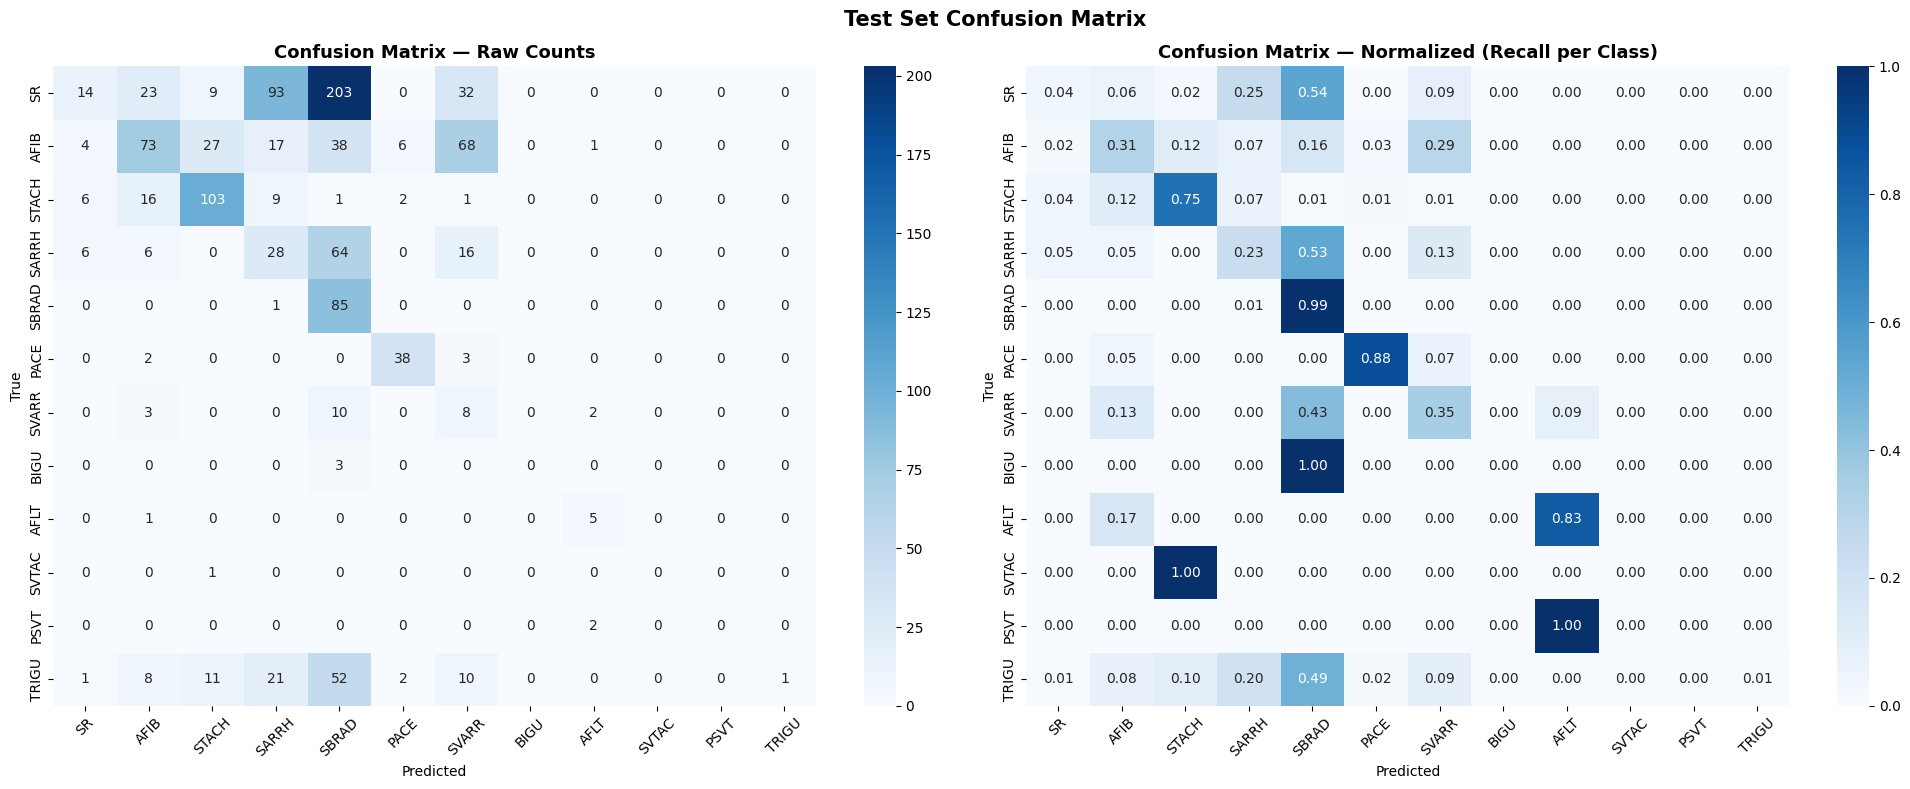

Saved: confusion_matrix.png


In [26]:
cm = confusion_matrix(test_labels, test_preds, labels=present_classes)

# Normalize by row (true labels) so each row sums to 1
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Raw counts ────────────────────────────────────────────────────────
sns.heatmap(
    cm, ax=axes[0],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# ── Normalized (recall per class) ─────────────────────────────────────
sns.heatmap(
    cm_normalized, ax=axes[1],
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — Normalized (Recall per Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Test Set Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

---
# **_▞▞ Per-Class F1 Bar Chart ▞▞_**

A quick visual to identify which arrhythmia types are hardest to classify.
---

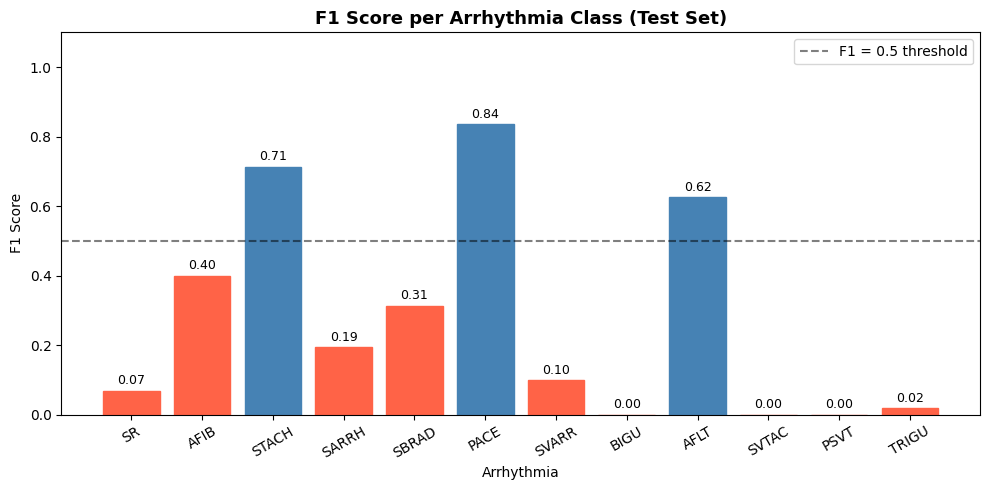

Saved: f1_per_class.png


In [27]:
f1_per_class = f1_score(test_labels, test_preds, labels=present_classes, average=None, zero_division=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(present_names, f1_per_class, color='steelblue', edgecolor='white')

# Color bars below 0.5 in red to highlight problem classes
for bar, score in zip(bars, f1_per_class):
    bar.set_color('tomato' if score < 0.5 else 'steelblue')
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}', ha='center', va='bottom', fontsize=9)

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='F1 = 0.5 threshold')
plt.title('F1 Score per Arrhythmia Class (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Arrhythmia')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_per_class.png")

---
# **_▞▞ Class Distribution Plot ▞▞_**

Visualize how balanced (or imbalanced) the dataset is after downsampling SR.
---

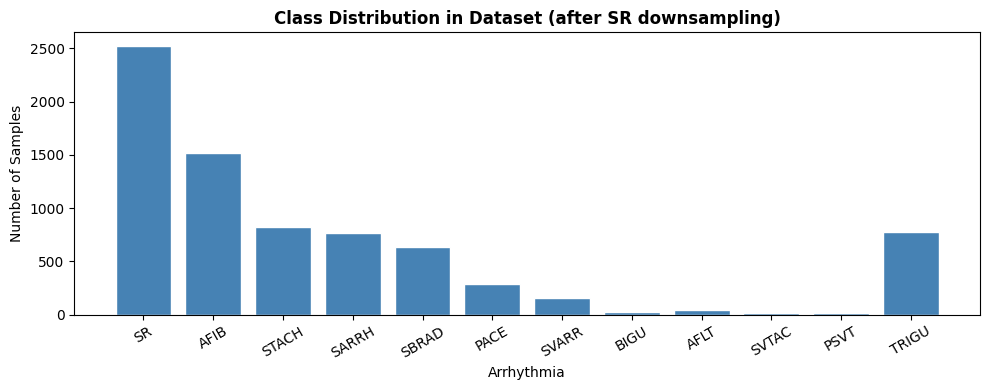

In [28]:
dist = dataset.df['target'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in dist.index], dist.values, color='steelblue', edgecolor='white')
plt.title('Class Distribution in Dataset (after SR downsampling)', fontsize=12, fontweight='bold')
plt.xlabel('Arrhythmia')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **_▞▞ Save Model ▞▞_**
---

In [ ]:
# Save the trained weights to your project folder
torch.save(model.state_dict(), 'REAL2_ecg_arrhythmia_model.pt')

In [ ]:
save_path = '/content/drive/MyDrive/TESIS-V2/ecg_arrhythmia_model_v2.pt'
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/TESIS-V2/ecg_arrhythmia_model_v2.pt


---
# **_▞▞ Single File Inference ▞▞_**

Run inference on a single `.dat` file. Set `inference_lead` to a number (0–11) to use only that lead, or `None` to use all 12.
---

In [30]:
inference_lead = LEAD_INDEX  # Match whatever the model was trained with

single_file_path = '/content/drive/MyDrive/TESIS-V2/Data/ptb-xl-1.0.3/records100/00000/00001_lr.dat'

with open(single_file_path, 'rb') as f:
    raw_data = np.fromfile(f, dtype=np.int16).reshape(1000, 12).astype(np.float32) / 1000.0

# Transpose to (12, 1000)
x = torch.tensor(raw_data).T

# Extract single lead if needed
if inference_lead is not None:
    x = x[inference_lead].unsqueeze(0)  # (1, 1000)

x_input = x.unsqueeze(0).to(device)  # Add batch dim: (1, leads, 1000)

model.eval()
with torch.no_grad():
    logits    = model(x_input)
    probs     = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_cls  = probs.argmax()

print(f"Predicted arrhythmia: {CLASS_NAMES[pred_cls]} (class {pred_cls})")
print("\nClass probabilities:")
for i, (name, prob) in enumerate(zip(CLASS_NAMES, probs)):
    bar = '█' * int(prob * 40)
    print(f"  {name:6s}: {prob:.4f}  {bar}")

Predicted arrhythmia: SBRAD (class 4)

Class probabilities:
  SR    : 0.1139  ████
  AFIB  : 0.0277  █
  STACH : 0.0001  
  SARRH : 0.1457  █████
  SBRAD : 0.4933  ███████████████████
  PACE  : 0.0019  
  SVARR : 0.0630  ██
  BIGU  : 0.0016  
  AFLT  : 0.0000  
  SVTAC : 0.0000  
  PSVT  : 0.0000  
  TRIGU : 0.1527  ██████
